## Import Libraries

In [1]:
import gymnasium as gym
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical 

import matplotlib.pyplot as plt

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

## Create Environment (CartPole-V1)

In [3]:
env = gym.make('CartPole-v1')

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"State dim: {state_dim}")
print(f"Action dim: {action_dim}")
print(f"Device : {device}")

State dim: 4
Action dim: 2
Device : cuda


## REINFORCEMENT w/o Baseline

In [4]:
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        """
        state_dim: input dim (4 for CartPole)
        action_dim: number of discrete actions (2 for CartPole)
        hidden_dim: hidden layer size
        """
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, action_dim)

    def forward(self, state):
        x = torch.relu(self.fc1(state))
        x = torch.relu(self.fc2(x))
        logits = self.fc3(x)
        return torch.softmax(logits, dim=-1)

In [5]:
def select_action(policy, state):
    """
    policy: state -> action probability -> action sampling

    Returns:
        action: selected action (int)
        log_prob: log pi(a|s), used to calculate gradient
    """
    state = torch.FloatTensor(state).unsqueeze(0).to(device) # (1, state_dim)
    probs = policy(state) # (1, action_dim)

    dist = Categorical(probs)
    action = dist.sample()
    log_prob = dist.log_prob(action)

    return action.item(), log_prob

In [7]:
def compute_returns(rewards, gamma=0.99):
    """
    rewards: list of rewards from one episode [r_0, r_1, ..., r_T]
    gamma: discount factor

    Returns:
        returns: normalized G_t for each timestep
    """
    returns = []
    G = 0
    # G_t = r_t + gamma * G_{t+1}
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)

    returns = torch.tensor(returns, dtype=torch.float32).to(device)
    # Normalize for training stability (reduces variance)
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    return returns

In [8]:
def update_policy(optimizer, log_probs, returns):
    """
    log_probs: list of log pi(a_t|s_t) collected during the episode
    returns: G_t for each timestep (normalized)

    Returns:
        Policy Gradient Loss: loss = -sum_t(G_t * log_prob_t)
    """
    loss = 0
    for log_prob_t, G_t in zip(log_probs, returns):
        loss += - G_t * log_prob_t

    optimizer.zero_grad()
    loss.backward()

    grad_norm = torch.nn.utils.clip_grad_norm_(
        optimizer.param_groups[0]['params'], max_norm=float('inf')
    )
    optimizer.step()

    return loss.item(), grad_norm.item()

In [9]:
def train(env, policy, optimizer, num_episodes=1000, gamma=0.99, print_every=50, early_stopping=True):
    episode_rewards = []
    grad_norms = []
    action0_probs = []

    ref_state, _ = env.reset(seed=9999)

    for episode in range(num_episodes):
        state, _ = env.reset()
        log_probs = []
        rewards = []
        done = False

        while not done:
            action, log_prob = select_action(policy, state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            log_probs.append(log_prob)
            rewards.append(reward)
            state = next_state

        returns = compute_returns(rewards, gamma)
        loss, grad_norm = update_policy(optimizer, log_probs, returns)
        grad_norms.append(grad_norm)

        total_reward = sum(rewards)
        episode_rewards.append(total_reward)

        with torch.no_grad():
            ref_probs = policy(torch.FloatTensor(ref_state).unsqueeze(0).to(device))
        action0_probs.append(ref_probs[0, 0].item())

        if (episode + 1) % print_every == 0:
            avg_reward = np.mean(episode_rewards[-100:])
            print(f"Episode {episode+1}/{num_episodes} | "
                  f"Reward: {total_reward:.0f} | "
                  f"Avg(last 100): {avg_reward:.1f} |"
                  f"Loss: {loss:.4f} | Grad Norm: {grad_norm:.4f}")

        if early_stopping and len(episode_rewards) >= 100 and np.mean(episode_rewards[-100:]) >= 195:
            print(f"\nSolved at episode {episode + 1}! "
                  f"Avg reward: {np.mean(episode_rewards[-100:]):.1f}")
            break

    return episode_rewards, grad_norms, action0_probs

In [10]:
# Run Training
policy = PolicyNetwork(state_dim, action_dim).to(device)
optimizer = optim.Adam(policy.parameters(), lr=1e-3)

episode_rewards, grad_norms, action0_probs = train(env, policy, optimizer, num_episodes=1000)

Episode 50/1000 | Reward: 24 | Avg(last 100): 20.5 |Loss: -0.2048 | Grad Norm: 2.7282
Episode 100/1000 | Reward: 62 | Avg(last 100): 25.1 |Loss: 1.7796 | Grad Norm: 11.4922
Episode 150/1000 | Reward: 45 | Avg(last 100): 36.7 |Loss: 1.7470 | Grad Norm: 6.3214
Episode 200/1000 | Reward: 181 | Avg(last 100): 54.1 |Loss: 4.7346 | Grad Norm: 14.1422
Episode 250/1000 | Reward: 53 | Avg(last 100): 89.3 |Loss: 0.5381 | Grad Norm: 9.6872
Episode 300/1000 | Reward: 174 | Avg(last 100): 148.9 |Loss: -9.3294 | Grad Norm: 30.1826
Episode 350/1000 | Reward: 181 | Avg(last 100): 154.8 |Loss: -2.3394 | Grad Norm: 28.3823

Solved at episode 367! Avg reward: 198.1


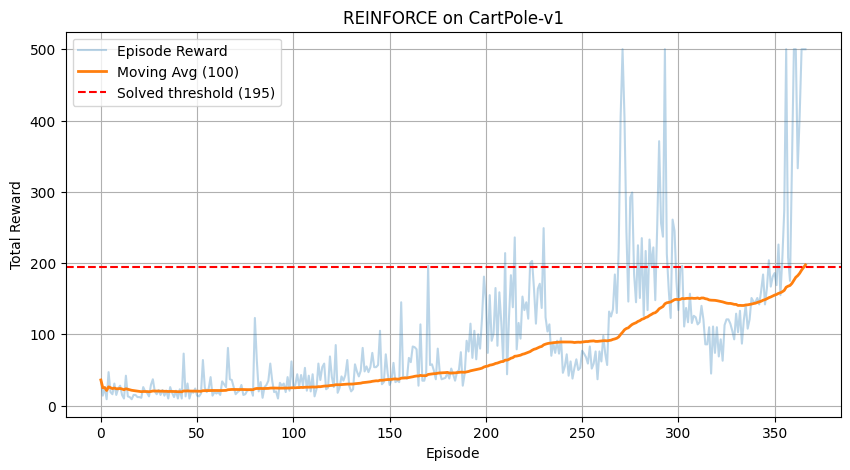

In [12]:
def moving_average(data, window=100):
    return [np.mean(data[max(0, i-window):i+1]) for i in range(len(data))]

plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, alpha=0.3, label='Episode Reward')
plt.plot(moving_average(episode_rewards), label='Moving Avg (100)', linewidth=2)
plt.axhline(y=195, color='r', linestyle='--', label='Solved threshold (195)')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('REINFORCE on CartPole-v1')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
def evaluate_policy(env_name, policy, num_episodes=20, greedy=True, seed=42):
    env = gym.make(env_name)
    total_rewards = []

    for ep in range(num_episodes):
        torch.manual_seed(seed + ep)
        state, _ = env.reset(seed=seed + ep)
        ep_reward = 0
        done = False
        while not done:
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            with torch.no_grad():
                probs = policy(state_t)
            if greedy:
                action = torch.argmax(probs, dim=-1).item()
            else:
                action = Categorical(probs).sample().item()
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_reward += reward
        total_rewards.append(ep_reward)

    env.close()
    print(f"Mean: {np.mean(total_rewards):.1f}, Std: {np.std(total_rewards):.1f}, Max: {np.max(total_rewards):.1f}, Min: {np.min(total_rewards):.1f}")
    return total_rewards

Mean: 471.1, Std: 53.3, Max: 500.0, Min: 313.0
Mean: 402.9, Std: 98.9, Max: 500.0, Min: 237.0


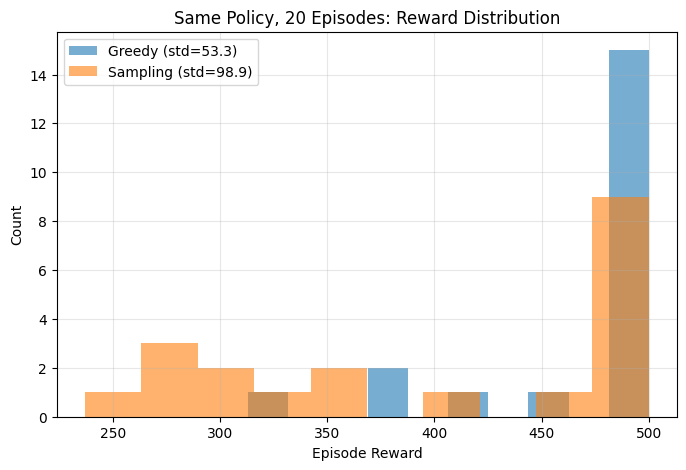

In [14]:
greedy_rewards   = evaluate_policy('CartPole-v1', policy, num_episodes=20, greedy=True, seed=50)
sampling_rewards = evaluate_policy('CartPole-v1', policy, num_episodes=20, greedy=False, seed=50)

plt.figure(figsize=(8, 5))
plt.hist(greedy_rewards, bins=10, alpha=0.6, label=f'Greedy (std={np.std(greedy_rewards):.1f})')
plt.hist(sampling_rewards, bins=10, alpha=0.6, label=f'Sampling (std={np.std(sampling_rewards):.1f})')
plt.xlabel('Episode Reward')
plt.ylabel('Count')
plt.title('Same Policy, 20 Episodes: Reward Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## REINFORCEMENT w/ Baseline

In [15]:
class ValueNetwork(nn.Module):
    def __init__(self, state_dim, hidden_dim=128):
        """
        state_dim: input dimension (4 for CartPole)
        hidden_dim: hidden layer size

        Returns:
            V(s): estimated expected return from state s
        """
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 1)

    def forward(self, state):
        x = torch.relu(self.fc1(state))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

In [16]:
def collect_episodes(env, policy):
    """
    Run one full episode and collect states, log_probs, rewards
    """
    state, _ = env.reset()
    states = []
    log_probs = []
    rewards = []
    done = False

    while not done:
        states.append(state)
        action, log_prob = select_action(policy, state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        log_probs.append(log_prob)
        rewards.append(reward)
        state = next_state

    return states, log_probs, rewards

In [17]:
def update_policy_with_baseline(policy_optimizer, value_optimizer,
                                value_net, states, log_probs, returns):
    """
    states: list of states from the episode
    log_probs: list of log pi(a_t|s_t)
    returns: G_t for each timestep

    Steps:
        1. Compute V(S_t) for all states
        2. Compute Advantage A_t = G_t - V(s_t) (baseline subtracted)
        3. Policy loss: -sum_t(A_t.detach() * log_prob_t)
        4. Value loss: MSE()
    """
    states_t = torch.FloatTensor(np.array(states)).to(device)
    values = value_net(states_t).squeeze(-1)

    advantages = returns - values

    # --- Policy Update ---
    policy_loss = 0
    for log_prob, A_t in zip(log_probs, advantages.detach()):
        policy_loss += -log_prob * A_t

    policy_optimizer.zero_grad()
    policy_loss.backward()
    policy_grad_norm = torch.nn.utils.clip_grad_norm_(
        policy_optimizer.param_groups[0]['params'], max_norm=float('inf')
    )
    policy_optimizer.step()

    # --- Value Update ---
    value_loss = nn.functional.mse_loss(values, returns)

    value_optimizer.zero_grad()
    value_loss.backward()
    value_optimizer.step()

    return policy_loss.item(), value_loss.item(), policy_grad_norm.item()

In [21]:
def train_with_baseline(env, policy, value_net, policy_optimizer, value_optimizer,
                        num_episodes=1000, gamma=0.99, print_every=50, early_stopping=True):
    episode_rewards = []
    grad_norms = []
    action0_probs = []
    value_means = []

    ref_state, _ = env.reset(seed=9999)

    for episode in range(num_episodes):
        states, log_probs, rewards = collect_episodes(env, policy)

        returns = compute_returns(rewards, gamma)
        p_loss, v_loss, grad_norm = update_policy_with_baseline(policy_optimizer, value_optimizer,
                                                     value_net, states, log_probs, returns)
        grad_norms.append(grad_norm)

        total_reward = sum(rewards)
        episode_rewards.append(total_reward)

        with torch.no_grad():
            ref_probs = policy(torch.FloatTensor(ref_state).unsqueeze(0).to(device))
            ref_value = value_net(torch.FloatTensor(ref_state).unsqueeze(0).to(device)).item()
        action0_probs.append(ref_probs[0, 0].item())
        value_means.append(ref_value)

        if (episode + 1) % print_every == 0:
            avg_reward = np.mean(episode_rewards[-100:])
            print(f"Episode {episode+1}/{num_episodes} | "
                  f"Reward: {total_reward:.0f} | "
                  f"Avg(last 100): {avg_reward:.1f} | "
                  f"P_Loss: {p_loss:.4f} | V_Loss: {v_loss:.4f} | Grad Norm: {grad_norm:.4f}")

        if early_stopping and len(episode_rewards) >= 100 and np.mean(episode_rewards[-100:]) >= 195:
            print(f"\nSolved at episode {episode + 1}! "
                  f"Avg reward: {np.mean(episode_rewards[-100:]):.1f}")
            break

    return episode_rewards, grad_norms, action0_probs, value_means

In [22]:
# Run training with baseline
policy_baseline = PolicyNetwork(state_dim, action_dim).to(device)
value_net       = ValueNetwork(state_dim).to(device)

policy_optimizer = optim.Adam(policy_baseline.parameters(), lr=1e-3)
value_optimizer  = optim.Adam(value_net.parameters(), lr=1e-3)

episode_rewards_baseline, grad_norms_baseline, action0_probs_baseline, value_means_baseline = train_with_baseline(
    env, policy_baseline, value_net, policy_optimizer, value_optimizer,
    num_episodes=1000
)

Episode 50/1000 | Reward: 25 | Avg(last 100): 24.4 | P_Loss: 0.8381 | V_Loss: 0.8731 | Grad Norm: 2.2625
Episode 100/1000 | Reward: 34 | Avg(last 100): 35.5 | P_Loss: 2.3208 | V_Loss: 0.8717 | Grad Norm: 6.5245
Episode 150/1000 | Reward: 132 | Avg(last 100): 94.0 | P_Loss: 58.8594 | V_Loss: 0.7007 | Grad Norm: 65.3006
Episode 200/1000 | Reward: 476 | Avg(last 100): 186.1 | P_Loss: 98.8769 | V_Loss: 0.5848 | Grad Norm: 42.8785

Solved at episode 203! Avg reward: 195.8


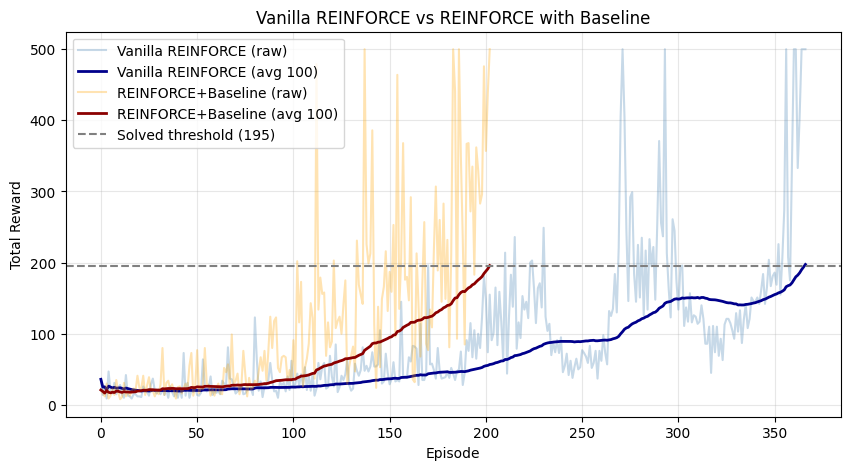

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, alpha=0.3, color='steelblue', label='Vanilla REINFORCE (raw)')
plt.plot(moving_average(episode_rewards), color='darkblue', linewidth=2, label='Vanilla REINFORCE (avg 100)')
plt.plot(episode_rewards_baseline, alpha=0.3, color='orange', label='REINFORCE+Baseline (raw)')
plt.plot(moving_average(episode_rewards_baseline), color='darkred', linewidth=2, label='REINFORCE+Baseline (avg 100)')
plt.axhline(y=195, color='gray', linestyle='--', label='Solved threshold (195)')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Vanilla REINFORCE vs REINFORCE with Baseline')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
print("Vanilla REINFORCE:")
vanilla_eval = evaluate_policy('CartPole-v1', policy, num_episodes=20, greedy=True)

print("\nREINFORCE with Baseline:")
baseline_eval = evaluate_policy('CartPole-v1', policy_baseline, num_episodes=20, greedy=True)

Vanilla REINFORCE:
Mean: 455.9, Std: 69.0, Max: 500.0, Min: 285.0

REINFORCE with Baseline:
Mean: 500.0, Std: 0.0, Max: 500.0, Min: 500.0


### Without Early Stopping

In [30]:
set_seed(42)
env.reset(seed=42)

policy_v1000 = PolicyNetwork(state_dim, action_dim).to(device)
optimizer_v1000 = optim.Adam(policy_v1000.parameters(), lr=1e-3)

print("=== Vanilla REINFORCE (1000 episodes, no early stopping) ===")
rewards_v1000, grads_v1000, action0_probs_v1000 = train(env, policy_v1000, optimizer_v1000,
                                                              num_episodes=1000, early_stopping=False)

set_seed(42)
env.reset(seed=42)

policy_b1000 = PolicyNetwork(state_dim, action_dim).to(device)
value_b1000 = ValueNetwork(state_dim).to(device)
policy_optimizer_b1000 = optim.Adam(policy_b1000.parameters(), lr=1e-3)
value_optimizer_b1000 = optim.Adam(value_b1000.parameters(), lr=1e-3)

print("\n=== REINFORCE with Baseline (500 episodes, no early stopping) ===")
rewards_b1000, grads_b1000, action0_probs_b1000, value_means_b1000 = train_with_baseline(env, policy_b1000, value_b1000,
                                                                                                     policy_optimizer_b1000, value_optimizer_b1000,
                                                                                                     num_episodes=1000, early_stopping=False)

=== Vanilla REINFORCE (1000 episodes, no early stopping) ===
Episode 50/1000 | Reward: 28 | Avg(last 100): 21.3 |Loss: -0.2708 | Grad Norm: 3.9070
Episode 100/1000 | Reward: 60 | Avg(last 100): 32.4 |Loss: 0.9774 | Grad Norm: 5.0196
Episode 150/1000 | Reward: 113 | Avg(last 100): 73.6 |Loss: -5.2003 | Grad Norm: 23.8803
Episode 200/1000 | Reward: 117 | Avg(last 100): 118.3 |Loss: -5.1926 | Grad Norm: 47.3905
Episode 250/1000 | Reward: 238 | Avg(last 100): 184.6 |Loss: 3.1148 | Grad Norm: 26.2790
Episode 300/1000 | Reward: 169 | Avg(last 100): 230.4 |Loss: -1.4018 | Grad Norm: 32.3890
Episode 350/1000 | Reward: 140 | Avg(last 100): 182.1 |Loss: 2.5810 | Grad Norm: 41.3064
Episode 400/1000 | Reward: 93 | Avg(last 100): 126.9 |Loss: -2.3754 | Grad Norm: 45.2043
Episode 450/1000 | Reward: 203 | Avg(last 100): 131.4 |Loss: -1.5381 | Grad Norm: 79.2392
Episode 500/1000 | Reward: 428 | Avg(last 100): 244.4 |Loss: 3.7159 | Grad Norm: 42.8911
Episode 550/1000 | Reward: 118 | Avg(last 100): 313.

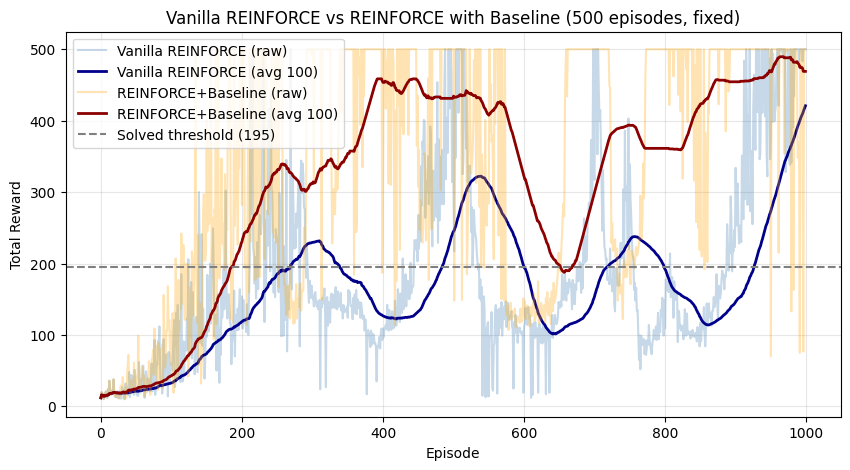

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(rewards_v1000, alpha=0.3, color='steelblue', label='Vanilla REINFORCE (raw)')
plt.plot(moving_average(rewards_v1000), color='darkblue', linewidth=2, label='Vanilla REINFORCE (avg 100)')
plt.plot(rewards_b1000, alpha=0.3, color='orange', label='REINFORCE+Baseline (raw)')
plt.plot(moving_average(rewards_b1000), color='darkred', linewidth=2, label='REINFORCE+Baseline (avg 100)')
plt.axhline(y=195, color='gray', linestyle='--', label='Solved threshold (195)')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Vanilla REINFORCE vs REINFORCE with Baseline (500 episodes, fixed)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

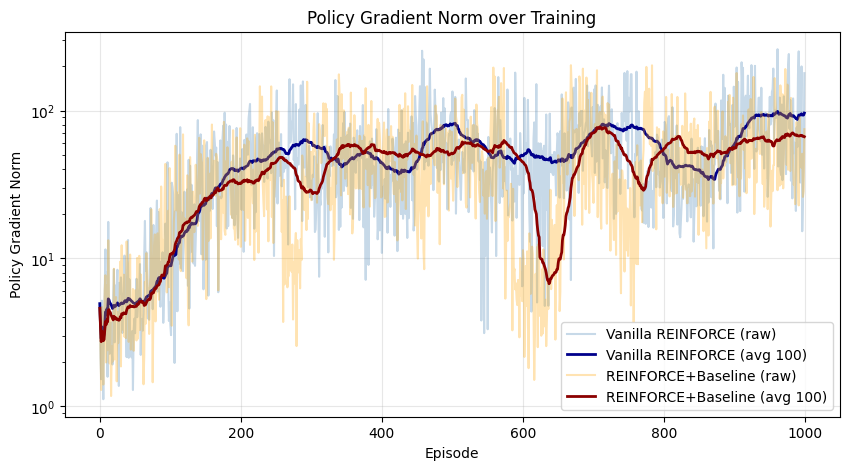

In [31]:
plt.figure(figsize=(10, 5))
plt.plot(grads_v1000, alpha=0.3, color='steelblue', label='Vanilla REINFORCE (raw)')
plt.plot(moving_average(grads_v1000, 50), color='darkblue', linewidth=2, label='Vanilla REINFORCE (avg 100)')
plt.plot(grads_b1000, alpha=0.3, color='orange', label='REINFORCE+Baseline (raw)')
plt.plot(moving_average(grads_b1000, 50), color='darkred', linewidth=2, label='REINFORCE+Baseline (avg 100)')
plt.xlabel('Episode')
plt.ylabel('Policy Gradient Norm')
plt.title('Policy Gradient Norm over Training')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

In [ ]:
np.save('results/rewards_vanilla_1000.npy', rewards_v1000)
np.save('results/rewards_baseline_1000.npy', rewards_b1000)
np.save('results/grads_vanilla_1000.npy', grads_v1000)
np.save('results/grads_baseline_1000.npy', grads_b1000)
np.save('results/action0_probs_vanilla_1000.npy', action0_probs_v1000)
np.save('results/action0_probs_baseline_1000.npy', action0_probs_b1000)
np.save('results/value_means_baseline_1000.npy', value_means_b1000)